**STEP 1: Import Libraries**

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**STEP 2: Load Data**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:

trades = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/historical_data.csv')
sentiment = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/fear_greed_index.csv')

In [6]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


**Step 3 : Convert Dates**

In [9]:
# Convert to datetime
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M', dayfirst=True)
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Extract only date
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

**STEP 5 : Merge Data**

In [10]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

In [12]:
merged.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [13]:
merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211218 entries, 0 to 211217
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211218 non-null  object        
 1   Coin              211218 non-null  object        
 2   Execution Price   211218 non-null  float64       
 3   Size Tokens       211218 non-null  float64       
 4   Size USD          211218 non-null  float64       
 5   Side              211218 non-null  object        
 6   Timestamp IST     211218 non-null  datetime64[ns]
 7   Start Position    211218 non-null  float64       
 8   Direction         211218 non-null  object        
 9   Closed PnL        211218 non-null  float64       
 10  Transaction Hash  211218 non-null  object        
 11  Order ID          211218 non-null  int64         
 12  Crossed           211218 non-null  bool          
 13  Fee               211218 non-null  float64       
 14  Trad

In [14]:
merged.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value
count,211218.000000,2.112180e+05,2.112180e+05,211218,2.112180e+05,211218.000000,2.112180e+05,211218.000000,2.112180e+05,2.112180e+05,2.112180e+05,211218.000000
mean,11415.047529,4.623341e+03,5.639192e+03,2025-01-31 12:08:21.724569344,-2.994671e+04,48.549304,6.965470e+10,1.163960,5.628506e+14,1.737745e+12,1.738301e+09,51.649656
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1.682919e+09,10.000000
25%,4.858550,2.940000e+00,1.937900e+02,2024-12-31 21:53:45,-3.760725e+02,0.000000,5.984223e+10,0.016121,2.810000e+14,1.740000e+12,1.735623e+09,33.000000
50%,18.280000,3.200000e+01,5.970200e+02,2025-02-24 18:55:00,8.477051e+01,0.000000,7.442939e+10,0.089572,5.620000e+14,1.740000e+12,1.740375e+09,49.000000
75%,101.895000,1.878900e+02,2.058878e+03,2025-04-02 18:22:00,9.337697e+03,5.790132,8.335543e+10,0.393774,8.460000e+14,1.740000e+12,1.743572e+09,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,1.746077e+09,94.000000
std,29448.010305,1.042744e+05,3.657557e+04,NaN,6.738170e+05,917.989791,1.835714e+10,6.758948,3.257541e+14,8.689946e+09,8.029302e+06,21.012784


**ANALYSIS STARTS HERE**

**1. Average Profit by Sentiment** :
   This analysis calculates the average profit (PnL) for trades under different market sentiment conditions (Fear vs Greed).

In [16]:
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


**2. Total Profit** : This step computes the total profit generated in each sentiment category to understand overall performance.

In [19]:
merged.groupby('classification')['Closed PnL'].sum()

,Closed PnL
classification,
Extreme Fear,7.391102e+05
Extreme Greed,2.715171e+06
Fear,3.357155e+06
Greed,2.150129e+06
Neutral,1.292921e+06


**3. Win Rate** : A new column is created to identify profitable trades. The win rate is then calculated as the proportion of profitable trades in each sentiment category.

In [20]:
merged['is_profit'] = merged['Closed PnL'] > 0
merged.groupby('classification')['is_profit'].mean()

,is_profit
classification,
Extreme Fear,0.370607
Extreme Greed,0.464943
Fear,0.420768
Greed,0.384828
Neutral,0.396991


**4. Risk Analysis** : This analysis shows how much capital traders deploy under different sentiments.

In [24]:
merged.groupby('classification')['Size USD'].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


**5. Buy vs Sell Behavior** : This step analyzes the distribution of buy and sell trades across different sentiment conditions to identify behavioral patterns.

In [26]:
pd.crosstab(merged['classification'], merged['Side'])

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


**6. Loss Analysis** : This analysis focuses on loss-making trades to understand how severe losses are under different market sentiments.

In [28]:
merged[merged['Closed PnL'] < 0].groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,-257.099629
Extreme Greed,-119.920289
Fear,-156.662401
Greed,-181.967329
Neutral,-121.727849


**7. Risk Efficiency** : Risk efficiency is calculated by dividing profit/loss by trade size. This helps evaluate how effectively traders generate returns relative to their risk.

In [29]:
merged['risk_ratio'] = merged['Closed PnL'] / merged['Size USD']

merged.groupby('classification')['risk_ratio'].mean()

,risk_ratio
classification,
Extreme Fear,0.004321
Extreme Greed,0.040027
Fear,0.015412
Greed,0.019653
Neutral,0.009936


**VISUALIZATIONS**

Profit Distribution : This boxplot visualizes the distribution of profits and losses under different sentiment conditions, highlighting variability and outliers.

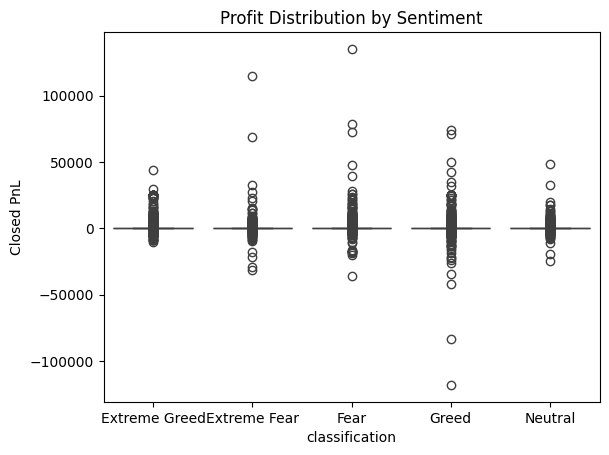

In [30]:
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("Profit Distribution by Sentiment")
plt.show()

Win Rate Graph : This bar chart shows the win rate comparison between Fear and Greed market conditions.

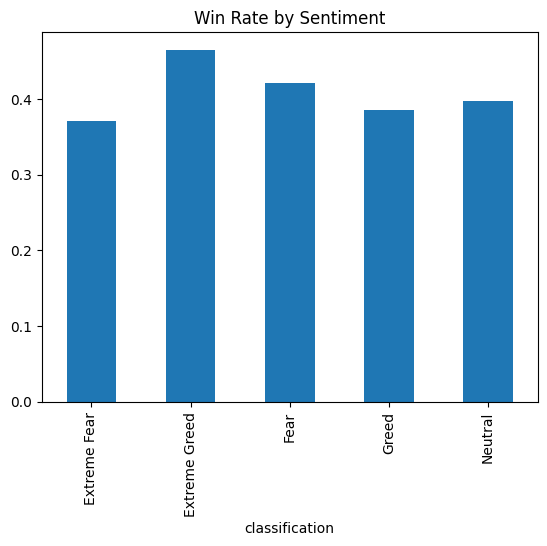

In [36]:
win_rate = merged.groupby('classification')['is_profit'].mean()

win_rate.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.show()

Risk (Trade Size) : This visualization compares the average trade size across sentiment categories, indicating differences in risk-taking behavior.

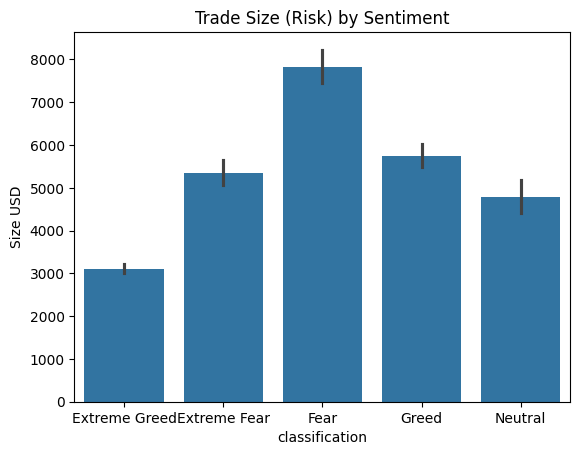

In [31]:
sns.barplot(x='classification', y='Size USD', data=merged)
plt.title("Trade Size (Risk) by Sentiment")
plt.show()

Buy/Sell Heatmap : This heatmap represents the frequency of buy and sell trades under each sentiment, helping identify trading patterns.

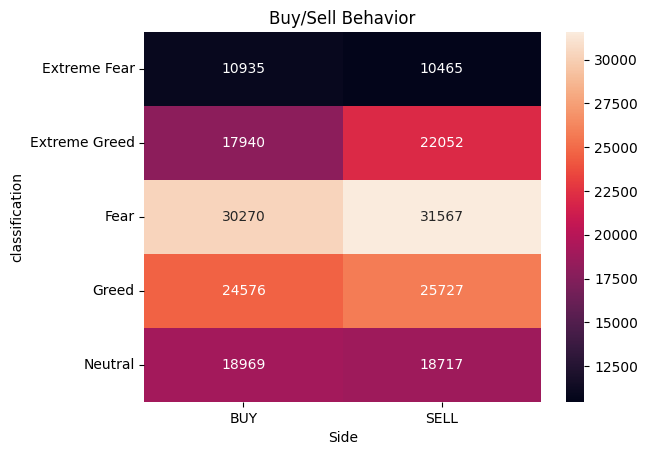

In [32]:
sns.heatmap(pd.crosstab(merged['classification'], merged['Side']), annot=True, fmt='d')
plt.title("Buy/Sell Behavior")
plt.show()

TOP TRADERS : This step identifies the top-performing traders based on total profit, providing insights into trader performance distribution.

In [34]:
top_traders = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)

top_traders.head(10)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05
